## Set Up

In [ ]:
pip install openpyxl

In [ ]:
pip install mglearn

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic' # Windows
# matplotlib.rcParams['font.family'] = 'AppleGothic' # Mac
matplotlib.rcParams['font.size'] = 15 # 글자 크기
matplotlib.rcParams['axes.unicode_minus'] = False # 한글 폰트 사용 시, 마이너스 글자가 깨지는 현상을 해결

#### Random Forest

훈련 세트 정확도 : 0.867
테스트 세트 정확도 : 0.856
특성 중요도 : 
[0.03762637 0.03429288 0.03491669 0.0336518  0.05198215 0.09263618
 0.07224897 0.11192329 0.09620018 0.01803096 0.00665254 0.0499956
 0.01730888 0.0422398  0.03902696 0.03074217 0.06628413 0.06310791
 0.10113252]


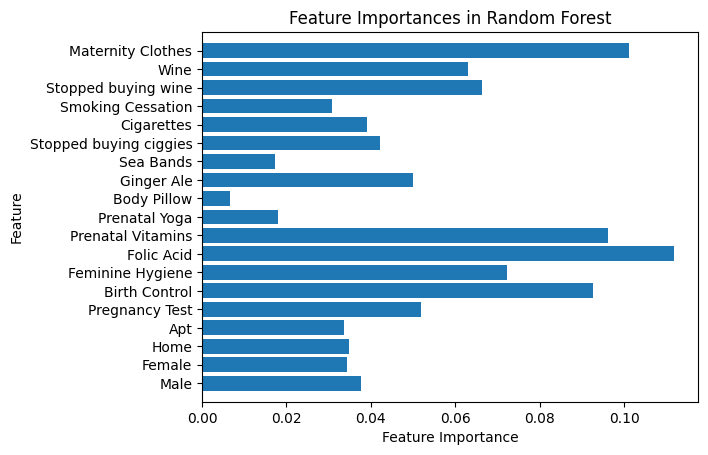

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 엑셀 파일 읽기
file_path = 'PREGNANT.xlsx'  # 엑셀 파일 경로를 입력하세요.
data = pd.read_excel(file_path, sheet_name=0)  # 첫 번째 시트를 읽어옵니다.

# 마지막 열을 target으로 설정하고 나머지는 features로 설정
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 훈련/테스트 세트로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 랜덤 포레스트 모델 학습
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

# 정확도 출력
print("훈련 세트 정확도 : {:.3f}".format(forest.score(X_train, y_train)))
print("테스트 세트 정확도 : {:.3f}".format(forest.score(X_test, y_test)))

# 특성 중요도 출력
print("특성 중요도 : \n{}".format(forest.feature_importances_))

# 특성 중요도 시각화
def plot_feature_importances(model, data):
    n_features = data.shape[1] - 1  # 마지막 열은 target이므로 제외
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), data.columns[:-1])  # target 열을 제외한 열 이름 사용
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)
    plt.title("Feature Importances in Random Forest")
    plt.show()

plot_feature_importances(forest, data)


#### Boosting

훈련 세트 정확도 : 0.844
테스트 세트 정확도 : 0.860
특성 중요도 : 
[0.02132757 0.00588718 0.00866089 0.00666087 0.05689779 0.12158096
 0.09414466 0.14821123 0.11618046 0.01388525 0.00284882 0.05188677
 0.0136557  0.03183586 0.02930175 0.01922083 0.0619995  0.07895805
 0.11685586]


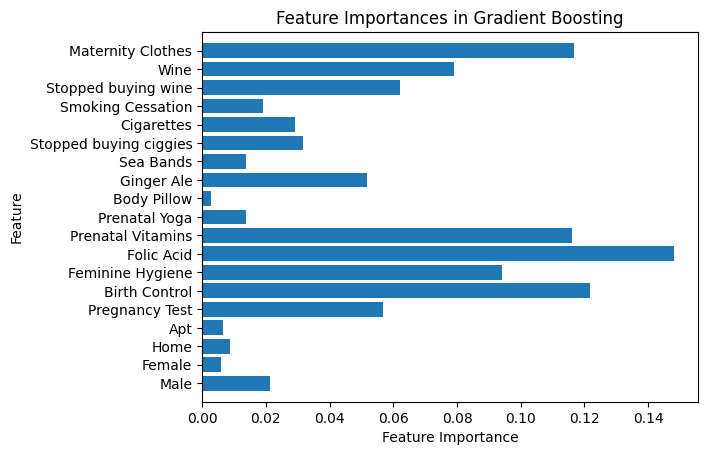

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 엑셀 파일 읽기
file_path = 'PREGNANT.xlsx'  # 엑셀 파일 경로를 입력하세요.
data = pd.read_excel(file_path, sheet_name=0)  # 첫 번째 시트를 읽어옵니다.

# 마지막 열을 target으로 설정하고 나머지는 features로 설정
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 훈련/테스트 세트로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Gradient Boosting 모델 학습
gradientboost = GradientBoostingClassifier(random_state=0)
gradientboost.fit(X_train, y_train)

# 정확도 출력
print("훈련 세트 정확도 : {:.3f}".format(gradientboost.score(X_train, y_train)))
print("테스트 세트 정확도 : {:.3f}".format(gradientboost.score(X_test, y_test)))

# 특성 중요도 출력
print("특성 중요도 : \n{}".format(gradientboost.feature_importances_))

# 특성 중요도 시각화
def plot_feature_importances(model, data):
    n_features = data.shape[1] - 1  # 마지막 열은 target이므로 제외
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), data.columns[:-1])  # target 열을 제외한 열 이름 사용
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)
    plt.title("Feature Importances in Gradient Boosting")
    plt.show()

plot_feature_importances(gradientboost, data)
